# Government720

## Centralized Training of Dataset

### Import Dataset

In [1]:
# Access Google Drive for Excel file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import pandas
import pandas as pd

# Open centralized G720 dataset
file_path = '/content/drive/My Drive/G720_CENTRALIZED.xlsx'
df = pd.read_excel(file_path)
display(df)

,DATE,UNEMPLOYMENT_RATE,INFLATION_RATE,GDP,HOUSING_AFFORD,MIN_WAGE,POVERTY_WAGE,GENDER_GAP,RACIAL_GAP,DEFICIT,...,CRIM_JUSTICE_OPINION,CYBERATTACKS,CYBERATTACK_LOSSES,ANTIGOV_HATE_GROUPS,BLACK_POLICE_KILLINGS,BLACK_POLICE_INJURIES,AGRI_SPENDING,FARMS,AGRI_SALES,GOVT_SATISFACTION
0,2000-01-01,0.090771,0.428571,0.000000,0.564941,0.000000,0.000000,1.000000,0.000000,0.842664,...,0.000000,0.648938,24.340056,0.000000,0.812500,0.149563,1.000000,0.747482,0.033151,0.984127
1,2000-01-02,0.088336,0.439460,-0.006451,0.582133,-0.015130,0.012035,1.012380,0.015080,0.866582,...,0.002436,0.650784,24.293744,0.002301,0.771343,0.161149,1.009763,0.755527,0.012815,0.969936
2,2000-01-03,0.068309,0.461814,0.020851,0.557502,0.002986,-0.003704,1.000877,0.012387,0.859851,...,0.007630,0.663887,24.243950,0.006832,0.791030,0.161093,0.973442,0.746970,0.045595,0.978186
3,2000-01-04,0.094006,0.466160,0.023599,0.569352,-0.012395,-0.024910,0.995282,0.023790,0.856962,...,-0.011947,0.673369,24.175841,0.002531,0.765967,0.152750,0.985362,0.749999,0.035259,0.963311
4,2000-02-01,0.080713,0.473214,-0.014477,0.578737,-0.006515,0.009105,1.000385,0.021138,0.862737,...,0.008481,0.689343,24.145127,0.011706,0.751976,0.170155,0.963912,0.731088,0.031125,0.956141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,2024-12-01,0.061404,0.446429,0.992084,0.553803,0.721304,0.947514,0.238885,0.359305,0.324283,...,1.034276,0.061653,3.169271,0.504834,0.690493,0.793153,0.518754,0.482968,0.284282,0.190476
1296,2024-12-02,0.068841,0.484023,1.003965,0.561947,0.723718,0.942604,0.245403,0.344826,0.331236,...,1.019945,0.072165,3.201947,0.487201,0.670080,0.807083,0.509532,0.472014,0.280977,0.186986
1297,2024-12-03,0.056386,0.491619,0.979914,0.555939,0.706159,0.947851,0.256613,0.355953,0.329730,...,1.018172,0.053037,3.210213,0.499356,0.675365,0.797039,0.511735,0.480155,0.284237,0.197936
1298,2024-12-04,0.047830,0.509606,0.975679,0.554174,0.699791,0.957607,0.235009,0.341437,0.323080,...,1.019598,0.086177,3.227715,0.497207,0.682760,0.796146,0.511684,0.471341,0.290775,0.194319


### Training and Testing Splitting

In [3]:
# Define split date for approximate 85-15 split
split_date = '2021-01-01'

# Define training and testing sets using boolean mask
train_mask = df['DATE'] < split_date
test_mask = df['DATE'] >= split_date
train_df = df[train_mask]
test_df = df[test_mask]

# Set DATE as index for both sets
train_df.set_index("DATE", inplace=True)
test_df.set_index("DATE", inplace=True)

# Print training and testing sets
display(train_df, test_df)

,UNEMPLOYMENT_RATE,INFLATION_RATE,GDP,HOUSING_AFFORD,MIN_WAGE,POVERTY_WAGE,GENDER_GAP,RACIAL_GAP,DEFICIT,SS_RECIPIENTS,...,CRIM_JUSTICE_OPINION,CYBERATTACKS,CYBERATTACK_LOSSES,ANTIGOV_HATE_GROUPS,BLACK_POLICE_KILLINGS,BLACK_POLICE_INJURIES,AGRI_SPENDING,FARMS,AGRI_SALES,GOVT_SATISFACTION
DATE,,,,,,,,,,,,,,,,,,,,,
2000-01-01,0.090771,0.428571,0.000000,0.564941,0.000000,0.000000,1.000000,0.000000,0.842664,0.000000,...,0.000000,0.648938,24.340056,0.000000,0.812500,0.149563,1.000000,0.747482,0.033151,0.984127
2000-01-02,0.088336,0.439460,-0.006451,0.582133,-0.015130,0.012035,1.012380,0.015080,0.866582,-0.012662,...,0.002436,0.650784,24.293744,0.002301,0.771343,0.161149,1.009763,0.755527,0.012815,0.969936
2000-01-03,0.068309,0.461814,0.020851,0.557502,0.002986,-0.003704,1.000877,0.012387,0.859851,-0.001014,...,0.007630,0.663887,24.243950,0.006832,0.791030,0.161093,0.973442,0.746970,0.045595,0.978186
2000-01-04,0.094006,0.466160,0.023599,0.569352,-0.012395,-0.024910,0.995282,0.023790,0.856962,-0.011743,...,-0.011947,0.673369,24.175841,0.002531,0.765967,0.152750,0.985362,0.749999,0.035259,0.963311
2000-02-01,0.080713,0.473214,-0.014477,0.578737,-0.006515,0.009105,1.000385,0.021138,0.862737,-0.002070,...,0.008481,0.689343,24.145127,0.011706,0.751976,0.170155,0.963912,0.731088,0.031125,0.956141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-01,0.289474,0.312500,0.639295,0.152647,1.003721,0.745564,0.299992,0.583022,0.116834,0.982335,...,1.053972,0.997981,0.523228,0.163511,0.271336,0.457333,0.239462,0.076931,0.686934,0.142857
2020-12-02,0.291578,0.311298,0.647978,0.153023,1.003362,0.742936,0.306398,0.579249,0.126534,0.964666,...,1.035790,1.010719,0.529567,0.180594,0.247924,0.459566,0.248467,0.085852,0.688751,0.119945
2020-12-03,0.271868,0.314350,0.635026,0.149373,1.003476,0.727810,0.313749,0.581159,0.124247,0.960071,...,1.041022,0.987039,0.553148,0.180144,0.263836,0.466268,0.239878,0.107146,0.695373,0.098995


,UNEMPLOYMENT_RATE,INFLATION_RATE,GDP,HOUSING_AFFORD,MIN_WAGE,POVERTY_WAGE,GENDER_GAP,RACIAL_GAP,DEFICIT,SS_RECIPIENTS,...,CRIM_JUSTICE_OPINION,CYBERATTACKS,CYBERATTACK_LOSSES,ANTIGOV_HATE_GROUPS,BLACK_POLICE_KILLINGS,BLACK_POLICE_INJURIES,AGRI_SPENDING,FARMS,AGRI_SALES,GOVT_SATISFACTION
DATE,,,,,,,,,,,,,,,,,,,,,
2021-01-01,0.263158,0.312500,0.647059,0.160000,1.000000,0.744582,0.318681,0.578947,0.128205,0.962768,...,1.042336,1.000000,0.552632,0.161252,0.250000,0.475212,0.233049,0.080905,0.707512,0.063492
2021-01-02,0.246787,0.333328,0.649179,0.154881,1.000576,0.751185,0.320828,0.560779,0.134581,0.956837,...,1.027808,1.005508,0.560424,0.186422,0.235046,0.457582,0.243032,0.100726,0.709987,0.138578
2021-01-03,0.241469,0.328542,0.652341,0.161113,1.002384,0.759455,0.313772,0.589773,0.151890,0.962294,...,1.044393,0.987501,0.573633,0.192872,0.252600,0.466402,0.254736,0.102040,0.708477,0.225280
2021-01-04,0.228069,0.337106,0.666078,0.165752,1.010941,0.759913,0.310414,0.589079,0.157929,0.976917,...,1.037192,0.989498,0.582214,0.182521,0.265887,0.466107,0.243709,0.104857,0.734605,0.317895
2021-02-01,0.245614,0.339286,0.667946,0.161959,1.001914,0.757475,0.301609,0.593260,0.139384,0.964989,...,1.051870,0.986637,0.572924,0.205517,0.284794,0.479628,0.246905,0.121032,0.731611,0.317460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-01,0.061404,0.446429,0.992084,0.553803,0.721304,0.947514,0.238885,0.359305,0.324283,1.017711,...,1.034276,0.061653,3.169271,0.504834,0.690493,0.793153,0.518754,0.482968,0.284282,0.190476
2024-12-02,0.068841,0.484023,1.003965,0.561947,0.723718,0.942604,0.245403,0.344826,0.331236,1.011052,...,1.019945,0.072165,3.201947,0.487201,0.670080,0.807083,0.509532,0.472014,0.280977,0.186986
2024-12-03,0.056386,0.491619,0.979914,0.555939,0.706159,0.947851,0.256613,0.355953,0.329730,1.013315,...,1.018172,0.053037,3.210213,0.499356,0.675365,0.797039,0.511735,0.480155,0.284237,0.197936


With 208 observations in testing set, this actually makes it an 84-16 split.

In [4]:
# Now split into X and y in both sets
X_train = train_df.drop('GOVT_SATISFACTION', axis=1)
y_train = train_df['GOVT_SATISFACTION']
X_test = test_df.drop('GOVT_SATISFACTION', axis=1)
y_test = test_df['GOVT_SATISFACTION']

# Print all sets
print("X_train:")
print(X_train)
print("\ny_train:")
print(y_train)
print("\nX_test:")
print(X_test)
print("\ny_test:")
print(y_test)

X_train:
            UNEMPLOYMENT_RATE  INFLATION_RATE       GDP  HOUSING_AFFORD  \
DATE                                                                      
2000-01-01           0.090771        0.428571  0.000000        0.564941   
2000-01-02           0.088336        0.439460 -0.006451        0.582133   
2000-01-03           0.068309        0.461814  0.020851        0.557502   
2000-01-04           0.094006        0.466160  0.023599        0.569352   
2000-02-01           0.080713        0.473214 -0.014477        0.578737   
...                       ...             ...       ...             ...   
2020-12-01           0.289474        0.312500  0.639295        0.152647   
2020-12-02           0.291578        0.311298  0.647978        0.153023   
2020-12-03           0.271868        0.314350  0.635026        0.149373   
2020-12-04           0.270880        0.327219  0.666045        0.162529   
2020-12-05           0.258173        0.323933  0.668965        0.153948   

            MIN

### RNN Model Setup

In [5]:
# Import model packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [6]:
# Data already MinMax scaled so no need for further preprocessing
# Convert DataFrames to NumPy arrays
X_train = X_train.values
X_test = X_test.values

# Reshape data for LSTM [samples, time steps, features]
time_steps = 1  # Use 1 time step for now, increase if predicting further into future
X_train = X_train.reshape(X_train.shape[0], time_steps, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], time_steps, X_test.shape[1])

# Build the LSTM Model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(time_steps, X_train.shape[2])))  # 50 LSTM units
model.add(Dense(1))  # Output layer with 1 unit for regression (GOVT_SATISFACTION)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Model Training

In [7]:
# Compile the Model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the Model
history = model.fit(X_train, y_train, epochs=50, verbose=1)

# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=1)
test_loss = model.evaluate(X_test, y_test, verbose=1)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0158
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0085
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0067
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0058
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0057
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0052
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0049
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0049
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0050
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042
Epoch 13/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042
Epoch 14/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0045
Epoch 15/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044
Epoch 16/50
35/35 ━

### Model Evaluation

In [8]:
# Import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Compute and print MSEs, MAEs and RMSEs
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MSE (Train): {train_loss:.4f}, MSE (Test): {test_loss:.4f}")
print(f"MAE (Train): {mae_train:.4f}, MAE (Test): {mae_test:.4f}")
print(f"RMSE (Train): {rmse_train:.4f}, RMSE (Test): {rmse_test:.4f}")

MSE (Train): 0.0033, MSE (Test): 0.0143
MAE (Train): 0.0446, MAE (Test): 0.1021
RMSE (Train): 0.0577, RMSE (Test): 0.1195


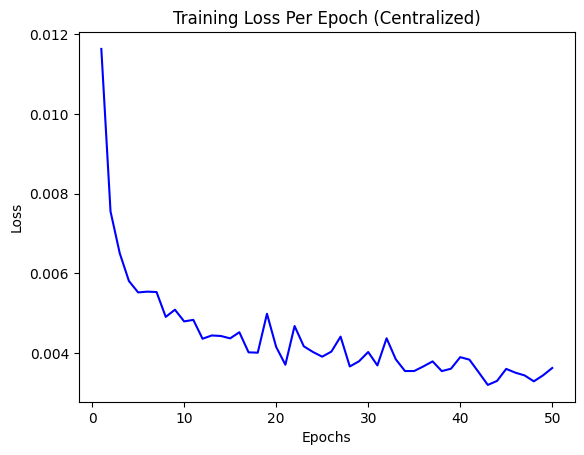

In [9]:
# First plot training loss
# Import matplotlib
import matplotlib.pyplot as plt

# Extract loss values from the history object
train_loss = history.history['loss']

# Plot training loss
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label='Training Loss', color='blue')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Per Epoch (Centralized)')
plt.show()

In [10]:
# Export to drive (will be used later for simultaneous loss comparison with FL and SL approaches)
loss_df = pd.DataFrame(history.history) # Convert to dataframe
display(loss_df)

# Define the file path
file_path = '/content/drive/My Drive/CL_loss_history.csv'

# Export the DataFrame to a CSV file
df.to_csv(file_path, index=False)
print(f"Loss history exported to: {file_path}")

,loss
0,0.011631
1,0.007554
2,0.006507
3,0.005808
4,0.005522
5,0.005542
6,0.005532
7,0.004908
8,0.005089
9,0.004795


Loss history exported to: /content/drive/My Drive/CL_loss_history.csv


In [11]:
# End of code 4/19/25